# Step 7 -- Pixel-based Anomaly Segmentation Baselines (ERFNet)

**Objective:** Run post-hoc anomaly detection methods on a **pixel-based**
semantic segmentation model (ERFNet) across five anomaly validation datasets.

**Methods implemented:**
- **MSP** (Maximum Softmax Probability): $1 - \max_c P(y=c|x)$
- **Max Logit**: $-\max_c f_c(x)$
- **Max Entropy**: $H(P) = -\sum_c P(y=c|x) \log P(y=c|x)$

**Datasets:** SMIYC RoadAnomaly21, SMIYC RoadObsticle21, FS Lost&Found,
FS Static, Road Anomaly

**Metrics:** AuPRC (area under precision-recall curve),
FPR@95TPR (false positive rate at 95% true positive rate)

## 1. Environment Setup

Clone the repository and extract the Cityscapes archives and anomaly-dataset zips
from Drive, then download the ERFNet weights.

Adjust the archive paths in the unzip commands to match your Drive layout.

In [ ]:
!git clone https://github.com/marinomic/MaskArchitectureAnomaly_CourseProject.git /content/MaskArchitectureAnomaly_CourseProject

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/datasets/cityscapes', exist_ok=True)
os.makedirs('/content/MaskArchitectureAnomaly_CourseProject/trained_models', exist_ok=True)

!unzip -q "/content/drive/MyDrive/project/datasets/leftImg8bit_trainvaltest.zip" -d /content/datasets/cityscapes
!unzip -q -o "/content/drive/MyDrive/project/datasets/gtFine_trainvaltest.zip" -d /content/datasets/cityscapes
!unzip -q "/content/drive/MyDrive/project/datasets/Anomaly_Validation_Datasets.zip" -d /content/MaskArchitectureAnomaly_CourseProject
!wget -q -O /content/MaskArchitectureAnomaly_CourseProject/trained_models/erfnet_pretrained.pth \
  https://github.com/Eromera/erfnet_pytorch/raw/master/trained_models/erfnet_pretrained.pth

Cloning into '/content/MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 29732, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 29732 (delta 36), reused 32 (delta 32), pack-reused 29651 (from 3)
Receiving objects: 100% (29732/29732), 1.36 GiB | 38.34 MiB/s, done.
Resolving deltas: 100% (3617/3617), done.
Updating files: 100% (21061/21061), done.
Error downloading object: Cityscapes val/gtFine_trainvaltest/README (09b2ded): Smudge error: Error downloading Cityscapes val/gtFine_trainvaltest/README (09b2dedebb5abff4ac106b012e5a870cd798bcd3336a160f25b6312e4abb9463): [09b2dedebb5abff4ac106b012e5a870cd798bcd3336a160f25b6312e4abb9463] Object does not exist on the server: [404] Object does not exist on the server

Errors logged to '/content/MaskArchitectureAnomaly_CourseProject/.git/lfs/logs/20260610T094726.333817659.log'.
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-proce

### Imports, Constants and Device

Set reproducibility seeds, define ERFNet constants (19 classes, 512x1024 input), build the transform pipeline, and select the compute device.

In [ ]:
import os
import glob
import json
import random
import os.path as osp
import sys
from collections import defaultdict

import torch
import numpy as np
from PIL import Image
from torch import nn, optim
from torchvision.datasets import Cityscapes
from torchvision.transforms import Compose, Resize, ToTensor

_ROOT = "/content/MaskArchitectureAnomaly_CourseProject"
sys.path.insert(0, osp.join(_ROOT, 'eval'))
sys.path.insert(0, osp.join(_ROOT, 'third_party', 'temperature_scaling'))

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

NUM_CHANNELS = 3
NUM_CLASSES = 20
IGNORE_INDEX = 19

input_transform = Compose([
    Resize((512, 1024), Image.BILINEAR),
    ToTensor(),
])

target_transform = Compose([
    Resize((512, 1024), Image.NEAREST),
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Evaluation Metrics (pure NumPy)

We implement AuPRC and FPR@95TPR **from scratch** without relying on
`sklearn` or external libraries, making the notebook self-contained. In the precision-recall computation, duplicate score thresholds are merged before the integral to avoid redundant work.

In [ ]:
def average_precision_score(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Area under the precision-recall curve (no sklearn dependency)."""
    y_true = np.asarray(y_true).astype(np.int64)
    y_score = np.asarray(y_score).astype(np.float64)
    if y_true.ndim != 1 or y_score.ndim != 1 or y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must be 1D arrays of the same length")

    pos = int(np.sum(y_true == 1))
    if pos == 0:
        return 0.0

    order = np.argsort(-y_score, kind="mergesort")
    y_true_sorted = y_true[order]

    tp = np.cumsum(y_true_sorted == 1)
    fp = np.cumsum(y_true_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / pos

    distinct = np.r_[True, y_score[order][1:] != y_score[order][:-1]]
    precision = precision[distinct]
    recall = recall[distinct]

    recall = np.r_[0.0, recall]
    precision = np.r_[precision[0], precision]

    return float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))


def fpr_at_95_tpr(y_score: np.ndarray, y_true: np.ndarray) -> float:
    """False positive rate when true positive rate reaches 95%."""
    y_true = np.asarray(y_true).astype(np.int64)
    y_score = np.asarray(y_score).astype(np.float64)
    if y_true.ndim != 1 or y_score.ndim != 1 or y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must be 1D arrays of the same length")

    pos = int(np.sum(y_true == 1))
    neg = int(np.sum(y_true == 0))
    if pos == 0 or neg == 0:
        return 0.0

    order = np.argsort(-y_score, kind="mergesort")
    y_true_sorted = y_true[order]

    tp = np.cumsum(y_true_sorted == 1)
    fp = np.cumsum(y_true_sorted == 0)

    tpr = tp / pos
    fpr = fp / neg

    idx = np.where(tpr >= 0.95)[0]
    if idx.size == 0:
        return 1.0
    return float(np.min(fpr[idx]))


print("Metrics defined: average_precision_score, fpr_at_95_tpr")

Metrics defined: average_precision_score, fpr_at_95_tpr


## 3. Anomaly Score Functions

Given per-pixel logits $f \in \mathbb{R}^{C \times H \times W}$,
each method produces an **anomaly heatmap** $A \in \mathbb{R}^{H \times W}$
where higher values indicate more anomalous pixels.

| Method | Formula | Intuition |
|--------|---------|-----------|
| **MSP** | $1 - \max_c \text{softmax}(f/T)_c$ | Low confidence -> anomaly |
| **Max Logit** | $-\max_c f_c$ | Low raw activation -> anomaly |
| **Max Entropy** | $-\sum_c p_c \log p_c$ | Uniform prediction -> anomaly |

Temperature $T$ scales logits before softmax: $p = \text{softmax}(f/T)$.
$T > 1$ flattens the distribution (more conservative).

In [ ]:
def anomaly_score_from_logits(
    logits: torch.Tensor, method: str, temperature: float = 1.0
) -> np.ndarray:
    """Convert per-pixel logits to an anomaly score map.

    Args:
        logits: Tensor of shape (B, C, H, W) -- raw model output.
        method: One of {"msp", "max_logit", "max_entropy"}.
        temperature: T > 0 for temperature scaling (default 1.0 = no scaling).

    Returns:
        np.ndarray of shape (H, W) -- anomaly scores.
    """
    temperature = max(float(temperature), 1e-8)
    scaled_logits = logits / temperature

    if method == "msp":
        probs = torch.softmax(scaled_logits, dim=1)
        score = 1.0 - probs.max(dim=1).values
        return score.squeeze(0).detach().cpu().numpy()

    if method == "max_logit":
        score = -logits.max(dim=1).values
        return score.squeeze(0).detach().cpu().numpy()

    if method == "max_entropy":
        log_probs = torch.log_softmax(scaled_logits, dim=1)
        probs = log_probs.exp()
        entropy = -(probs * log_probs).sum(dim=1)
        return entropy.squeeze(0).detach().cpu().numpy()

    raise ValueError(f"Unknown method: {method}")


print("anomaly_score_from_logits ready (msp | max_logit | max_entropy)")

anomaly_score_from_logits ready (msp | max_logit | max_entropy)


## 4. Dataset Helpers

Each anomaly dataset has a slightly different ground-truth format:

- **RoadAnomaly / RoadAnomaly21**: label `2` -> anomaly
- **FS Lost&Found**: label `0` = void, `1` = road, `>1` -> anomaly
- **RoadObsticle21 / fs_static**: standard binary (0 = in-dist, 1 = anomaly) Extension mismatches between image files and glob patterns are resolved. Ground-truth masks are remapped to {0: in-distribution, 1: anomaly}; in the RoadAnomaly dataset label ID 2 is the anomaly class.

In [ ]:
def infer_dataset_name(input_pattern: str) -> str:
    """Extract dataset name from input glob pattern."""
    norm = input_pattern.replace("\\", "/")
    parts = [p for p in norm.split("/") if p]
    if "Validation_Dataset" in parts:
        idx = parts.index("Validation_Dataset")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    if len(parts) >= 2:
        return parts[-2]
    return input_pattern


def load_gt_mask(path: str, pred_size: tuple) -> np.ndarray | None:
    """Load and normalise a ground-truth anomaly mask.

    Returns None if the mask file is missing.
    """
    pathGT = path.replace("images", "labels_masks")
    if "RoadObsticle21" in pathGT:
        pathGT = pathGT.replace("webp", "png")
    if "fs_static" in pathGT:
        pathGT = pathGT.replace("jpg", "png")
    if "RoadAnomaly" in pathGT:
        pathGT = pathGT.replace("jpg", "png")

    if not osp.exists(pathGT):
        return None

    mask = Image.open(pathGT)
    if mask.size != (pred_size[1], pred_size[0]):
        mask = mask.resize((pred_size[1], pred_size[0]), Image.NEAREST)
    ood_gts = np.array(mask)

    if "RoadAnomaly" in pathGT:
        ood_gts = np.where((ood_gts == 2), 1, ood_gts)

    if ("LostAndFound" in pathGT) or ("LostFound" in pathGT) or ("FS_LostFound_full" in pathGT):
        unique_vals = set(np.unique(ood_gts).tolist())
        if not unique_vals.issubset({0, 1, 255}):
            ood_gts = np.where((ood_gts == 0), 255, ood_gts)
            ood_gts = np.where((ood_gts == 1), 0, ood_gts)
            ood_gts = np.where((ood_gts > 1) & (ood_gts < 201), 1, ood_gts)

    if "Streethazard" in pathGT:
        ood_gts = np.where((ood_gts == 14), 255, ood_gts)
        ood_gts = np.where((ood_gts < 20), 0, ood_gts)
        ood_gts = np.where((ood_gts == 255), 1, ood_gts)

    return ood_gts


print("Dataset helpers ready")

Dataset helpers ready


## 5. Load ERFNet Model

In [ ]:
from erfnet import ERFNet

MODEL_DIR     = osp.join(_ROOT, 'trained_models')
MODEL_WEIGHTS = 'erfnet_pretrained.pth'

print(f'Loading model from: {MODEL_DIR}')
print(f'Weights: {MODEL_WEIGHTS}')

model = ERFNet(NUM_CLASSES)

if device.type == 'cuda':
    model = torch.nn.DataParallel(model).to(device)
else:
    model = model.to(device)


def load_my_state_dict(model, state_dict):
    """Custom loader -- handles 'module.' prefix from DataParallel."""
    own_state = model.state_dict()
    for name, param in state_dict.items():
        if name not in own_state:
            if name.startswith('module.'):
                own_state[name.split('module.')[-1]].copy_(param)
            else:
                print(f'  [skip] {name}')
                continue
        else:
            own_state[name].copy_(param)
    return model


weightspath = osp.join(MODEL_DIR, MODEL_WEIGHTS)
state = torch.load(weightspath, map_location=lambda storage, loc: storage)
model = load_my_state_dict(model, state)
model.eval()

print('ERFNet model loaded and ready for inference.')

Loading model from: /content/MaskArchitectureAnomaly_CourseProject/trained_models
Weights: erfnet_pretrained.pth
ERFNet model loaded and ready for inference.


## 6. Run Evaluation -- All Datasets x All Methods

Loop through every validation dataset, run the forward pass once,
compute anomaly scores for each method, and record AuPRC / FPR@95TPR. Results are stored as results[dataset][method] = {auprc, fpr95}. For each dataset, all logits are collected in a single forward pass; MSP, MaxLogit, and MaxEntropy then run on the same cached tensors.

In [ ]:
_VAL_DIR = osp.join(_ROOT, 'Validation_Dataset')
DATASETS = {
    "RoadAnomaly21":  osp.join(_VAL_DIR, "RoadAnomaly21",     "images", "*.png"),
    "RoadObsticle21": osp.join(_VAL_DIR, "RoadObsticle21",    "images", "*.webp"),
    "FS_LostFound":   osp.join(_VAL_DIR, "FS_LostFound_full", "images", "*.png"),
    "FS_Static":      osp.join(_VAL_DIR, "fs_static",         "images", "*.jpg"),
    "RoadAnomaly":    osp.join(_VAL_DIR, "RoadAnomaly",       "images", "*.jpg"),
}

METHODS = ["msp", "max_logit", "max_entropy"]

results = {}

for ds_name, ds_pattern in DATASETS.items():
    results[ds_name] = {}
    image_paths = sorted(glob.glob(os.path.expanduser(ds_pattern)))
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name}  ({len(image_paths)} images)")
    print(f"{'='*60}")

    if len(image_paths) == 0:
        print("  WARNING: No images found -- skipping.")
        continue

    all_logits = []
    all_gts = []

    for path in image_paths:
        img = Image.open(path).convert("RGB")
        img_tensor = input_transform(img).unsqueeze(0).float().to(device)

        with torch.no_grad():
            logits = model(img_tensor)

        gt = load_gt_mask(path, pred_size=logits.shape[-2:])
        if gt is None:
            continue
        if 1 not in np.unique(gt):
            continue

        all_logits.append(logits.squeeze(0).cpu())
        all_gts.append(gt)
        torch.cuda.empty_cache()

    if len(all_gts) == 0:
        print("  No valid samples with anomaly pixels.")
        continue

    for method in METHODS:
        anomaly_scores = []
        for logits_tensor in all_logits:
            score_map = anomaly_score_from_logits(
                logits_tensor.unsqueeze(0), method, temperature=1.0
            )
            anomaly_scores.append(score_map)

        gt_all = np.concatenate([g.flatten() for g in all_gts])
        scores_all = np.concatenate([s.flatten() for s in anomaly_scores])

        ood_mask = (gt_all == 1)
        ind_mask = (gt_all == 0)

        ood_out = scores_all[ood_mask]
        ind_out = scores_all[ind_mask]

        val_out = np.concatenate([ind_out, ood_out])
        val_label = np.concatenate([np.zeros(len(ind_out)), np.ones(len(ood_out))])

        auprc = average_precision_score(val_label, val_out)
        fpr95 = fpr_at_95_tpr(val_out, val_label)

        results[ds_name][method] = {"auprc": auprc, "fpr95": fpr95}
        print(f"  {method:>12s}  |  AuPRC: {auprc*100:5.2f}%  |  FPR@95: {fpr95*100:5.2f}%")

print("\n\nEvaluation complete!")


Dataset: RoadAnomaly21  (10 images)
           msp  |  AuPRC: 29.10%  |  FPR@95: 62.55%
     max_logit  |  AuPRC: 38.32%  |  FPR@95: 59.34%
   max_entropy  |  AuPRC: 30.97%  |  FPR@95: 62.66%

Dataset: RoadObsticle21  (30 images)
           msp  |  AuPRC:  2.71%  |  FPR@95: 65.23%
     max_logit  |  AuPRC:  4.63%  |  FPR@95: 48.44%
   max_entropy  |  AuPRC:  3.04%  |  FPR@95: 65.91%

Dataset: FS_LostFound  (100 images)
           msp  |  AuPRC:  1.75%  |  FPR@95: 50.60%
     max_logit  |  AuPRC:  3.30%  |  FPR@95: 45.49%
   max_entropy  |  AuPRC:  2.58%  |  FPR@95: 50.16%

Dataset: FS_Static  (30 images)
           msp  |  AuPRC:  7.47%  |  FPR@95: 41.84%
     max_logit  |  AuPRC:  9.50%  |  FPR@95: 40.30%
   max_entropy  |  AuPRC:  8.84%  |  FPR@95: 41.55%

Dataset: RoadAnomaly  (60 images)
           msp  |  AuPRC: 12.42%  |  FPR@95: 82.58%
     max_logit  |  AuPRC: 15.58%  |  FPR@95: 73.25%
   max_entropy  |  AuPRC: 12.67%  |  FPR@95: 82.75%


Evaluation complete!


## 7. Temperature Scaling

Fit a single temperature $T$ on the **Cityscapes validation set** by
minimising the negative log-likelihood (NLL), then re-evaluate MSP at
different temperatures.

`CITYSCAPES_DIR` is set to `/content/datasets/cityscapes`, the same
location where Step 4 extracts `gtFine_trainvaltest.zip` and
`leftImg8bit_trainvaltest.zip`. Run Step 4's extraction cell first, or
run these two commands before this cell:
```
!unzip -qo {CITYSCAPES_GT_ZIP}  -d /content/datasets/cityscapes/
!unzip -qo {CITYSCAPES_IMG_ZIP} -d /content/datasets/cityscapes/
```
where `CITYSCAPES_GT_ZIP` and `CITYSCAPES_IMG_ZIP` follow the Step 4
convention (`PROJECT_DIR/gtFine_trainvaltest.zip` etc.). If the directory
is absent the cell prints a warning and skips gracefully.

> **Pro tip:** Save the model logits to disk first, then try different
> $T$ values without re-running the forward pass. The label mapping converts Cityscapes raw label IDs (0-33) to the 19 train IDs used by the model. Unmapped IDs become 255 (ignore).

In [ ]:
from dataset import cityscapes
from temperature_scaling import _ECELoss

print("Collecting logits on Cityscapes validation set for temperature fitting...")

class LabelIdsToTrainIds:
    def __init__(self, ignore_index: int = IGNORE_INDEX):
        mapping = np.full(256, 255, dtype=np.uint8)
        for cls in Cityscapes.classes:
            if cls.id < 0:
                continue
            train_id = cls.train_id
            if train_id == 255 or cls.ignore_in_eval:
                mapping[cls.id] = 255
            else:
                mapping[cls.id] = train_id
        mapping[255] = 255
        self.mapping = mapping
        self.ignore_index = ignore_index

    def __call__(self, image):
        label_ids = np.array(image, dtype=np.uint8)
        train_ids = self.mapping[label_ids]
        train_ids[train_ids == 255] = self.ignore_index
        return torch.from_numpy(train_ids.astype(np.int64)).unsqueeze(0)


input_transform_cs = Compose([Resize(512, Image.BILINEAR), ToTensor()])
target_transform_cs = Compose([Resize(512, Image.NEAREST), LabelIdsToTrainIds()])


class SegmentationTemperatureScaler(nn.Module):
    """Learnable temperature parameter for logit calibration."""

    def __init__(self, init_temperature: float = 1.5):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * float(init_temperature))

    def temperature_scale(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature.clamp_min(1e-8)

    def set_temperature(self, logits, labels, device):
        nll_criterion = nn.CrossEntropyLoss().to(device)
        ece_criterion = _ECELoss().to(device)

        logits = logits.to(device)
        labels = labels.to(device)

        before_nll = nll_criterion(logits, labels).item()
        before_ece = ece_criterion(logits, labels).item()
        print(f"Before temperature - NLL: {before_nll:.4f}, ECE: {before_ece:.4f}")

        optimizer = optim.LBFGS([self.temperature], lr=0.01, max_iter=200)

        def closure():
            optimizer.zero_grad()
            loss = nll_criterion(self.temperature_scale(logits), labels)
            loss.backward()
            return loss

        optimizer.step(closure)

        after_nll = nll_criterion(self.temperature_scale(logits), labels).item()
        after_ece = ece_criterion(self.temperature_scale(logits), labels).item()
        best_t = float(self.temperature.item())

        print(f"Optimal temperature: {best_t:.4f}")
        print(f"After temperature  - NLL: {after_nll:.4f}, ECE: {after_ece:.4f}")

        return {
            "temperature": best_t,
            "before_nll": before_nll, "after_nll": after_nll,
            "before_ece": before_ece, "after_ece": after_ece,
        }

### 7b. Cityscapes Validation Loop and Temperature Fitting

Collect logits on the full Cityscapes val set and fit a single temperature scalar T on the NLL. The mIoU uses full-resolution predictions and a 20x20 confusion matrix; the void class (index 19) is excluded from the mean.

In [ ]:
CITYSCAPES_DIR = "/content/datasets/cityscapes"
ERFNET_MIOU = None

if not osp.exists(CITYSCAPES_DIR):
    print(f"WARNING: Cityscapes directory not found at '{CITYSCAPES_DIR}'.")
    print("Temperature scaling requires the Cityscapes validation set.")
    print("Please download it and update CITYSCAPES_DIR.")
else:
    loader = torch.utils.data.DataLoader(
        cityscapes(CITYSCAPES_DIR, input_transform_cs, target_transform_cs,
                   subset="val", label_suffix="_labelIds.png"),
        num_workers=4, batch_size=1, shuffle=False,
    )

    logits_list, labels_list = [], []
    MAX_PIXELS_PER_IMAGE = 4096
    conf_matrix = np.zeros((20, 20), dtype=np.int64)

    with torch.no_grad():
        for step, (images, labels, filename, _) in enumerate(loader):
            images = images.to(device)
            outputs = model(images)

            pred_full = outputs.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int64)
            gt_full = labels.squeeze(0).squeeze(0).cpu().numpy().astype(np.int64)
            valid_px = gt_full != IGNORE_INDEX
            p_flat = pred_full[valid_px].ravel()
            g_flat = gt_full[valid_px].ravel()
            conf_matrix += np.bincount(20 * g_flat + p_flat, minlength=400).reshape(20, 20)

            logits_flat = outputs.permute(0, 2, 3, 1).reshape(-1, outputs.shape[1])
            labels_flat = labels.squeeze(1).reshape(-1)
            valid = labels_flat != IGNORE_INDEX
            logits_flat = logits_flat[valid]
            labels_flat = labels_flat[valid]

            if logits_flat.numel() == 0:
                continue

            if logits_flat.shape[0] > MAX_PIXELS_PER_IMAGE:
                idx = torch.randperm(logits_flat.shape[0])[:MAX_PIXELS_PER_IMAGE]
                logits_flat = logits_flat[idx]
                labels_flat = labels_flat[idx]

            logits_list.append(logits_flat.cpu())
            labels_list.append(labels_flat.cpu())

            if step % 25 == 0:
                print(f"  [{step}] {logits_flat.shape[0]} valid pixels "
                      f"from {osp.basename(filename[0])}")

    intersection   = np.diag(conf_matrix[:19, :19])
    gt_per_class   = conf_matrix[:19, :].sum(axis=1)
    pred_per_class = conf_matrix[:19, :19].sum(axis=0)
    union          = gt_per_class + pred_per_class - intersection
    valid_cls      = union > 0
    iou_per_class  = np.where(valid_cls,
                              intersection / np.where(valid_cls, union, 1.0),
                              0.0)
    ERFNET_MIOU = float(np.mean(iou_per_class[valid_cls])) * 100
    print(f"\nERFNet mIoU on Cityscapes val (19 classes): {ERFNET_MIOU:.2f}%")

    logits_all = torch.cat(logits_list, dim=0)
    labels_all = torch.cat(labels_list, dim=0)
    print(f"Collected logits: {tuple(logits_all.shape)}, "
          f"labels: {tuple(labels_all.shape)}")

    scaler = SegmentationTemperatureScaler(init_temperature=1.5).to(device)
    stats = scaler.set_temperature(logits_all, labels_all, device)
    BEST_T_ERFNET = stats["temperature"]
    print(f"\nBest temperature for ERFNet: {BEST_T_ERFNET:.4f}")

/content/datasets/cityscapes/leftImg8bit/val /content/datasets/cityscapes/gtFine/val


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  [0] 4096 valid pixels from frankfurt_000000_000294_leftImg8bit.png
  [25] 4096 valid pixels from frankfurt_000000_011461_leftImg8bit.png
  [50] 4096 valid pixels from frankfurt_000001_000538_leftImg8bit.png
  [75] 4096 valid pixels from frankfurt_000001_010444_leftImg8bit.png
  [100] 4096 valid pixels from frankfurt_000001_017459_leftImg8bit.png
  [125] 4096 valid pixels from frankfurt_000001_029600_leftImg8bit.png
  [150] 4096 valid pixels from frankfurt_000001_041517_leftImg8bit.png
  [175] 4096 valid pixels from frankfurt_000001_049770_leftImg8bit.png
  [200] 4096 valid pixels from frankfurt_000001_058057_leftImg8bit.png
  [225] 4096 valid pixels from frankfurt_000001_065160_leftImg8bit.png
  [250] 4096 valid pixels from frankfurt_000001_073911_leftImg8bit.png
  [275] 4096 valid pixels from lindau_000008_000019_leftImg8bit.png
  [300] 4096 valid pixels from lindau_000033_000019_leftImg8bit.png
  [325] 4096 valid pixels from lindau_000058_000019_leftImg8bit.png
  [350] 4096 valid p

## 8. Results Summary Table

Compile all results into the table format required by the assignment.

| Model | mIoU | Method | SMIYC RA-21 AuPRC | SMIYC RA-21 FPR95 | ... | Road Anomaly AuPRC | Road Anomaly FPR95 |
|-------|------|--------|-------------------|--------------------|-----|---------------------|---------------------|
| ERFNet | -- | MSP | ... | ... | ... | ... | ... |
| ERFNet | -- | Max Logit | ... | ... | ... | ... | ... |
| ERFNet | -- | Max Entropy | ... | ... | ... | ... | ... | An optional pandas pivot table is also generated for quick comparison.

In [ ]:
def build_results_table(results_dict, model_name="ERFNet", miou="--"):
    """Print results in a flat format."""
    print(f"\n{'='*80}")
    print(f"Model: {model_name}  |  mIoU: {miou}")
    print(f"{'='*80}")
    print(f"{'Method':>12s} | {'Dataset':<20s} | {'AuPRC':>8s} | {'FPR@95':>8s}")
    print(f"{'-'*12}-+-{'-'*20}-+-{'-'*8}-+-{'-'*8}")

    for ds_name in DATASETS:
        if ds_name not in results_dict:
            continue
        for method in METHODS:
            if method not in results_dict[ds_name]:
                continue
            r = results_dict[ds_name][method]
            print(f"{method:>12s} | {ds_name:<20s} "
                  f"| {r['auprc']*100:7.2f}% | {r['fpr95']*100:7.2f}%")


miou_str = f"{ERFNET_MIOU:.2f}%" if ERFNET_MIOU is not None else "--"
build_results_table(results, model_name="ERFNet", miou=miou_str)

try:
    import pandas as pd
    rows = []
    for ds_name in results:
        for method in results[ds_name]:
            r = results[ds_name][method]
            rows.append({
                "Model": "ERFNet", "mIoU": miou_str, "Method": method,
                "Dataset": ds_name,
                "AuPRC": round(r["auprc"] * 100, 2),
                "FPR95": round(r["fpr95"] * 100, 2),
            })
    df = pd.DataFrame(rows)
    pivot = df.pivot_table(
        index=["Model", "mIoU", "Method"],
        columns="Dataset",
        values=["AuPRC", "FPR95"],
        aggfunc="first"
    )
    print("\n\n=== Assignment-ready pivot table ===")
    print(pivot.to_string())
except ImportError:
    print("\n(pandas not available -- install 'pip install pandas' for pivot table)")


Model: ERFNet  |  mIoU: 72.17%
      Method | Dataset              |    AuPRC |   FPR@95
-------------+----------------------+----------+---------
         msp | RoadAnomaly21        |   29.10% |   62.55%
   max_logit | RoadAnomaly21        |   38.32% |   59.34%
 max_entropy | RoadAnomaly21        |   30.97% |   62.66%
         msp | RoadObsticle21       |    2.71% |   65.23%
   max_logit | RoadObsticle21       |    4.63% |   48.44%
 max_entropy | RoadObsticle21       |    3.04% |   65.91%
         msp | FS_LostFound         |    1.75% |   50.60%
   max_logit | FS_LostFound         |    3.30% |   45.49%
 max_entropy | FS_LostFound         |    2.58% |   50.16%
         msp | FS_Static            |    7.47% |   41.84%
   max_logit | FS_Static            |    9.50% |   40.30%
 max_entropy | FS_Static            |    8.84% |   41.55%
         msp | RoadAnomaly          |   12.42% |   82.58%
   max_logit | RoadAnomaly          |   15.58% |   73.25%
 max_entropy | RoadAnomaly          |   

## 9. Results Analysis

Visualise AuPRC and FPR@95 across all five benchmarks for each method,
and the per-class IoU computed during the temperature-scaling loop.

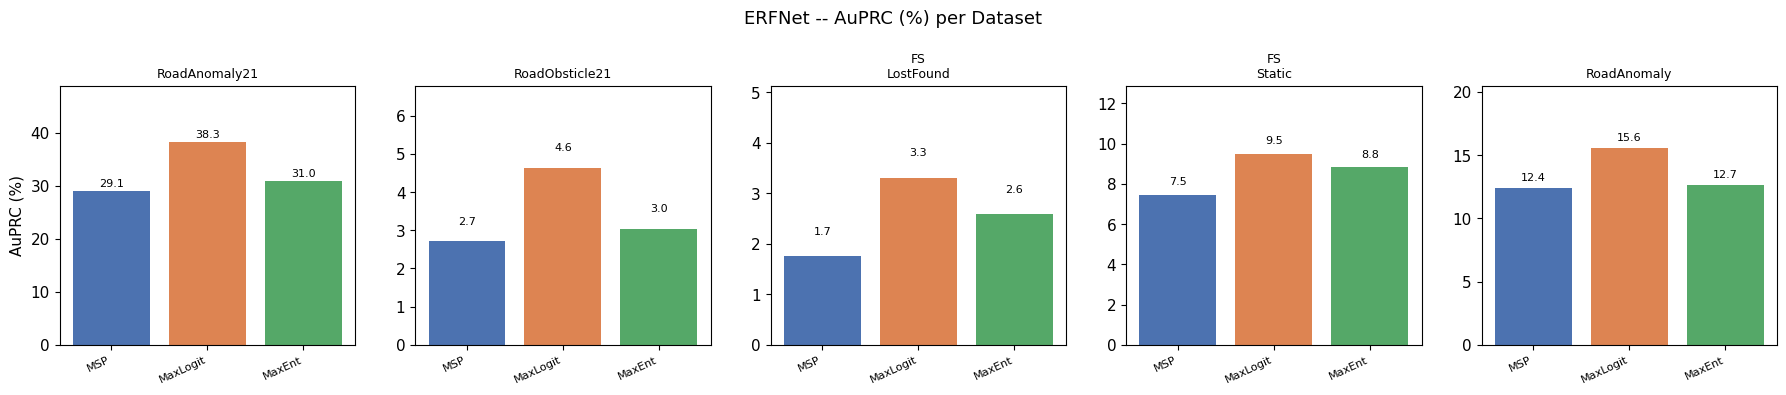

Saved: /content/MaskArchitectureAnomaly_CourseProject/results/step7_auprc_by_dataset.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 11})

_DS_LABELS = ["RoadAnomaly21", "RoadObsticle21", "FS_LostFound", "FS_Static", "RoadAnomaly"]
_COLORS = {"msp": "#4C72B0", "max_logit": "#DD8452", "max_entropy": "#55A868"}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("ERFNet -- AuPRC (%) per Dataset", fontsize=13)

for ax, ds in zip(axes, _DS_LABELS):
    vals = [
        results.get(ds, {}).get(m, {}).get("auprc", 0.0) * 100
        for m in ["msp", "max_logit", "max_entropy"]
    ]
    bars = ax.bar(range(3), vals, color=[_COLORS[m] for m in ["msp", "max_logit", "max_entropy"]])
    ax.set_title(ds.replace("_", "\n"), fontsize=9)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["MSP", "MaxLogit", "MaxEnt"], rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, max(vals + [1]) * 1.25 + 1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel("AuPRC (%)")
plt.tight_layout()
_out = osp.join(_ROOT, "results", "step7_auprc_by_dataset.png")
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_out}")

### FPR@95 per Dataset (lower is better)

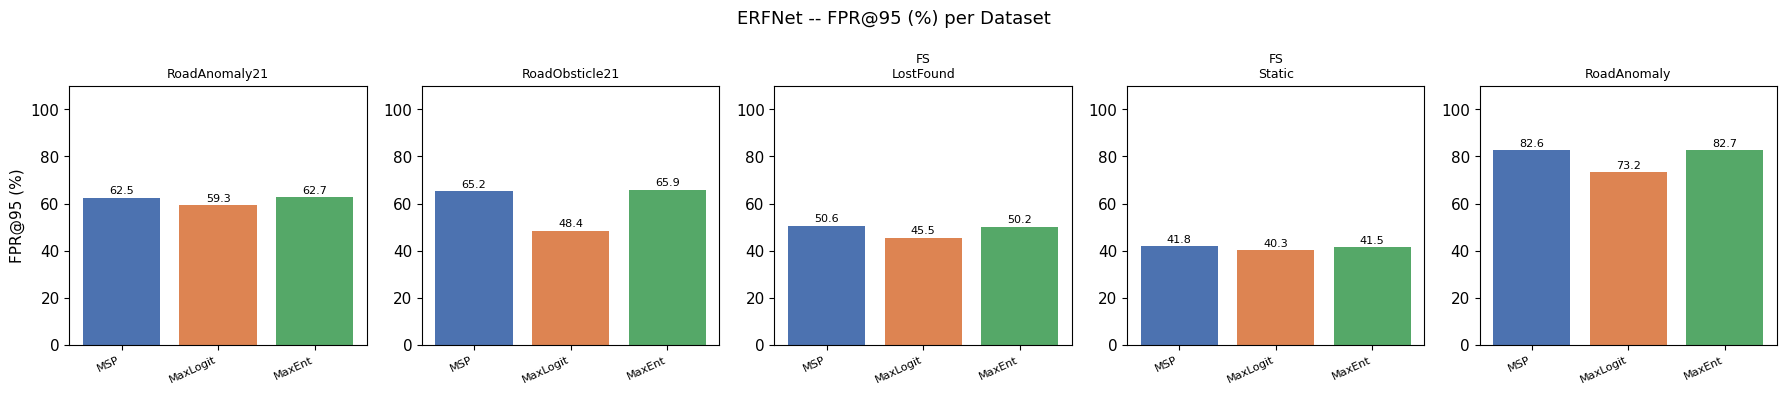

Saved: /content/MaskArchitectureAnomaly_CourseProject/results/step7_fpr95_by_dataset.png


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("ERFNet -- FPR@95 (%) per Dataset", fontsize=13)

for ax, ds in zip(axes, _DS_LABELS):
    vals = [
        results.get(ds, {}).get(m, {}).get("fpr95", 0.0) * 100
        for m in ["msp", "max_logit", "max_entropy"]
    ]
    bars = ax.bar(range(3), vals, color=[_COLORS[m] for m in ["msp", "max_logit", "max_entropy"]])
    ax.set_title(ds.replace("_", "\n"), fontsize=9)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["MSP", "MaxLogit", "MaxEnt"], rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel("FPR@95 (%)")
plt.tight_layout()
_out = osp.join(_ROOT, "results", "step7_fpr95_by_dataset.png")
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_out}")

### ERFNet Per-class IoU on Cityscapes Val

Requires the temperature-scaling loop above to have run with Cityscapes data available.

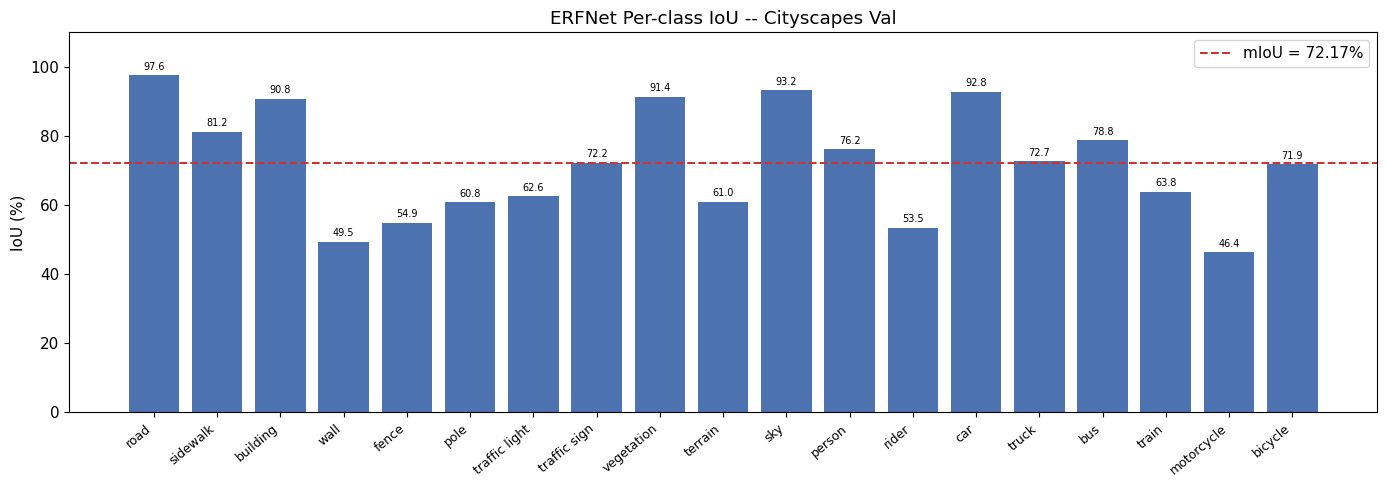

Saved: /content/MaskArchitectureAnomaly_CourseProject/results/step7_erfnet_per_class_iou.png


In [ ]:
_CS_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck", "bus", "train",
    "motorcycle", "bicycle",
]

try:
    _iou_vals = iou_per_class
    _iou_ok = ERFNET_MIOU is not None
except NameError:
    _iou_ok = False

if _iou_ok:
    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(19)
    bars = ax.bar(x, _iou_vals * 100, color="#4C72B0")
    ax.axhline(ERFNET_MIOU, color="#CC3333", linestyle="--",
               label=f"mIoU = {ERFNET_MIOU:.2f}%")
    ax.set_xticks(x)
    ax.set_xticklabels(_CS_CLASSES, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("IoU (%)")
    ax.set_title("ERFNet Per-class IoU -- Cityscapes Val")
    ax.legend()
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, _iou_vals * 100):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
                    f"{val:.1f}", ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    _out = osp.join(_ROOT, "results", "step7_erfnet_per_class_iou.png")
    plt.savefig(_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_out}")
else:
    print("Cityscapes data not available -- run the temperature-scaling cell to generate this chart.")

**End of Step 7 notebook.**